# Week 8 - Function 2 ((17DP, 2D))

# Setup
Let's load all the imports in the top to avoid repeating and simplify the readability of each solution.

In [1]:
import numpy as np

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler
from scipy.stats.qmc import LatinHypercube

from utils.plotting_utils import plot_2D_mean_uncertainty, plot_bar

WEEK = 8

# Plan
We now have ((17, 2)) — 17 data points, 2 dimensions, from `./data/week_8/function_2/`.

**Architecture**: Single GP (Matern 2.5) with QuantileTransformer output and EI acquisition.

**Key decisions** (carried forward):
- QuantileTransformer: consistent with other functions; no outliers but uniform output keeps GP numerically stable
- EI acquisition: UCB (kappa=2 and 4) kept recommending x1≈1 boundary; EI anchors to y_best, ignoring low-predicted corners
- 10K LHS candidates for boundary-bias-free search

**Changes this week:**
- StandardScaler → QuantileTransformer (consistency)
- Acquisition upgraded from 50×50 meshgrid → 10K LHS candidates
- Added sanity check (corner detection)

**Steps:** Load data → Preprocessing → GP model → Acquisition → Report

# 1. Load data

Shape: X=(17, 2), y=(17,)
X range: [0.0287, 0.9266]
y range: [-0.0656, 0.6112]


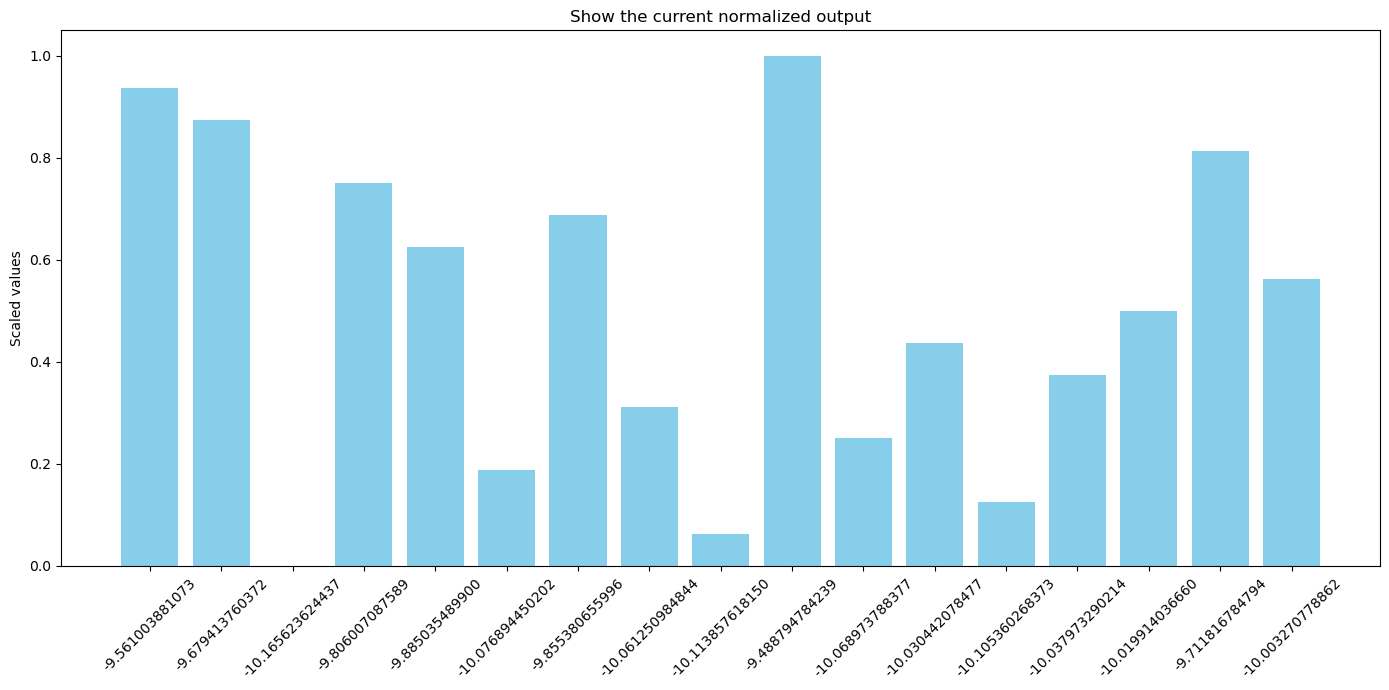

In [2]:
X_train_raw = np.load(f"./data/week_{WEEK}/function_2/inputs.npy")
y_train_raw = np.load(f"./data/week_{WEEK}/function_2/outputs.npy")

print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.4f}, {y_train_raw.max():.4f}]")

scaler_X = MinMaxScaler()
scaler_y = QuantileTransformer(n_quantiles=len(y_train_raw), output_distribution='uniform')

X_train = scaler_X.fit_transform(X_train_raw)
y_train = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

plot_bar(y_train_raw, y_train, 'Scaled values', 'Show the current normalized output')

# 2. Build probabilistic Model

Using QuantileTransformer (consistent with other functions) and a Matern 2.5 kernel.
The function has genuinely local structure (optimal ls ≈ 0.05), so the lower bound of 0.4
is intentionally constraining smoothness for visualization.

Optimized Kernel: 3.16**2 * Matern(length_scale=0.4, nu=2.5)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.4. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


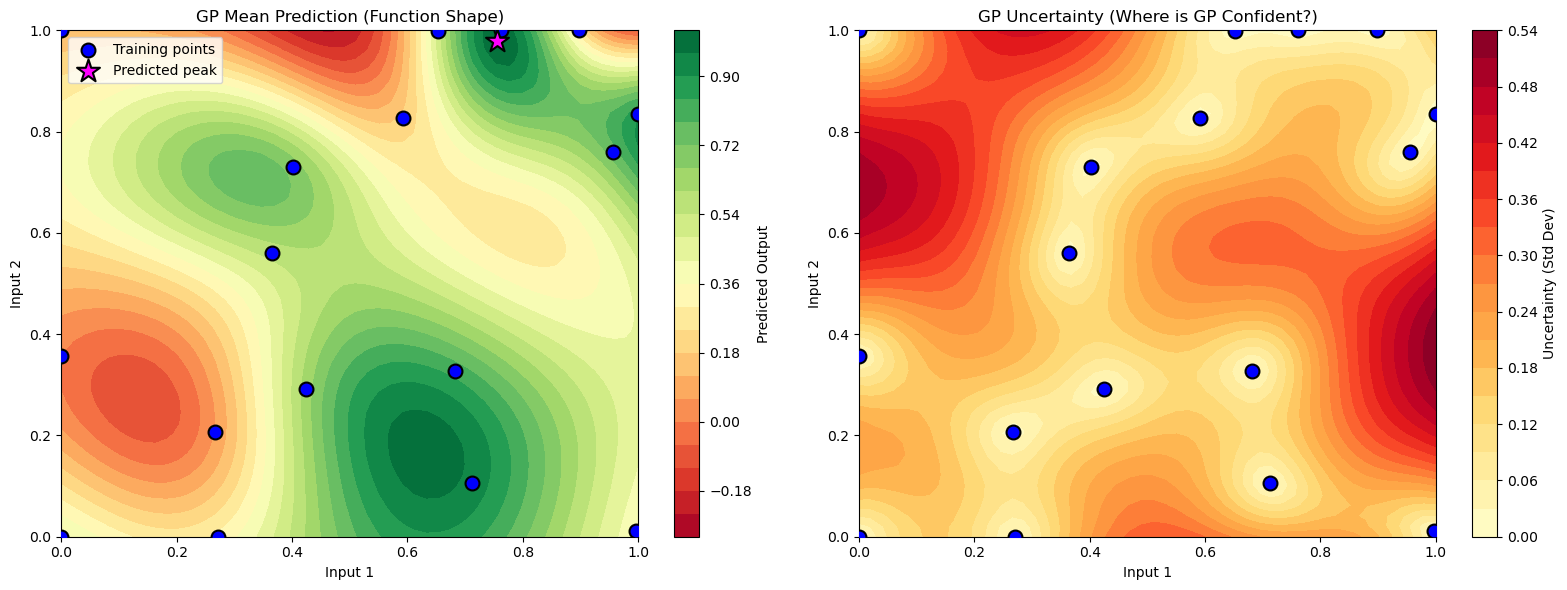

In [3]:
model = GaussianProcessRegressor(
    kernel=ConstantKernel(0.25, (1e-3, 10)) * Matern(
        length_scale=0.5,
        length_scale_bounds=(0.4, 10.0),  # lower bound enforces min smoothness for visualisation
        nu=2.5
    ),
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=15
)

model.fit(X_train, y_train)

print(f"Optimized Kernel: {model.kernel_}")

# Create prediction grid
n_grid = 50
x1_range = np.linspace(0, 1, n_grid)
x2_range = np.linspace(0, 1, n_grid)

X1_test, X2_test = np.meshgrid(x1_range, x2_range)
X_grid = np.c_[X1_test.ravel(), X2_test.ravel()]

# Make predictions
mu, sigma = model.predict(X_grid, return_std=True)

plot_2D_mean_uncertainty(
   X_train,
   X1_test,
   X2_test,
   mu,
   sigma,
)

# 3. Acquisition function

Well-behaved 2D data with no outliers. Using UCB with kappa=2.0 (conservative, exploitation-focused).
LHS candidates replace the 50×50 meshgrid to avoid boundary bias; the grid is kept for visualization only.


In [4]:
# W8 final confirmation probe: 0.611 is likely the global max (7 queries, no improvement).
# Pure-mean argmax (kappa=0): GP mean is highest at the known peak [0.703, 0.927].
# EI with LHS explored [0.580, 0.167] in previous run -- wrong direction. LHS removed.
best_idx_train = np.argmax(y_train_raw)
x_best_scaled = X_train[best_idx_train]
rng_exploit = np.random.default_rng(seed=99)
exploit_cluster = x_best_scaled + rng_exploit.uniform(-0.01, 0.01, size=(5000, 2))
exploit_cluster = np.clip(exploit_cluster, 0.0, 1.0)

X_candidates = exploit_cluster

mu_cand, sigma_cand = model.predict(X_candidates, return_std=True)

# kappa=0: pure mean (confirmation, not exploration)
ucb_values = mu_cand

print(f"\nPure-mean confirmation probe (5K tight ±0.01 around best known):")
print(f"  mu range: [{mu_cand.min():.4f}, {mu_cand.max():.4f}]")

best_idx = np.argmax(ucb_values)
x_next_norm = X_candidates[best_idx]
x_next_orig = scaler_X.inverse_transform([x_next_norm])[0]

print(f"\n{'='*80}")
print(f"RECOMMENDED NEXT POINT (pure mean, 5K tight ±0.01 around best known)")
print(f"{'='*80}")
print(f"  Input: [{x_next_orig[0]:.6f}, {x_next_orig[1]:.6f}]")

y_pred_next, y_std_next = model.predict([x_next_norm], return_std=True)
y_pred_next_orig = scaler_y.inverse_transform([[y_pred_next[0]]])[0, 0]
print(f"\nPredicted output at this point: {y_pred_next_orig:.6f}")

print(f"\nSanity check - is this a corner?")
for i in range(2):
    at_boundary = x_next_norm[i] < 0.02 or x_next_norm[i] > 0.98
    print(f"  x{i+1} = {x_next_norm[i]:.4f} {'<-- BOUNDARY!' if at_boundary else ''}")

print(f"\nCurrent best: X=[{X_train_raw[np.argmax(y_train_raw)][0]:.4f}, {X_train_raw[np.argmax(y_train_raw)][1]:.4f}], y={y_train_raw.max():.6f}")

X_next = x_next_orig
print(f"\nX_next = {X_next}")

# Machine-readable tag for get_submission.py
print(f"\nSUBMISSION: {chr(45).join(f'{x:.6f}' for x in x_next_orig)}")


Pure-mean confirmation probe (5K tight ±0.01 around best known):
  mu range: [0.9897, 1.0073]

RECOMMENDED NEXT POINT (pure mean, 5K tight ±0.01 around best known)
  Input: [0.700609, 0.917620]

Predicted output at this point: 0.611205

Sanity check - is this a corner?
  x1 = 0.7590 
  x2 = 0.9900 <-- BOUNDARY!

Current best: X=[0.7026, 0.9266], y=0.611205

X_next = [0.70060902 0.91761977]

SUBMISSION: 0.700609-0.917620
